**Uncomment the cell below if running on Google Colab or Kaggle**

In [1]:
# %%capture
# !pip3 install -U torch torchvision torchaudio
# !pip3 install -U fastai==2.7.2
# !pip3 install -U kaggle==1.5.12
# !pip3 install -U Pillow==9.1.0
# !pip3 install -U timm==0.5.4 # more stable fewer models
# !pip3 install -U git+https://github.com/rwightman/pytorch-image-models.git # more models less stable

**Note for Colab:**  You must restart the runtime in order to use newly installed version of Pillow.

**Import all fastai computer vision functionality**

In [2]:
from fastai.vision.all import *

In [3]:
import pandas as pd
pd.set_option('max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
import timm

In [5]:
timm.__version__

'0.6.2.dev0'

**Check available pretrained model types**

In [6]:
model_types = list(set([model.split('_')[0] for model in timm.list_models(pretrained=True)]))
model_types.sort()
pd.DataFrame(model_types)

,0
0,adv
1,bat
2,beit
3,botnet26t
4,cait
5,coat
6,convit
7,convmixer
8,convnext
9,crossvit


**Check available pretrained [ConvNeXt](https://arxiv.org/abs/2201.03545) models**

In [7]:
pd.DataFrame(timm.list_models('convnext*', pretrained=True))

,0
0,convnext_base
1,convnext_base_384_in22ft1k
2,convnext_base_in22ft1k
3,convnext_base_in22k
4,convnext_large
5,convnext_large_384_in22ft1k
6,convnext_large_in22ft1k
7,convnext_large_in22k
8,convnext_small
9,convnext_small_384_in22ft1k


In [8]:
from timm.models import convnext
convnext_model = 'convnext_tiny'
convnext.default_cfgs[convnext_model]

{'url': 'https://dl.fbaipublicfiles.com/convnext/convnext_tiny_1k_224_ema.pth',
 'num_classes': 1000,
 'input_size': (3, 224, 224),
 'pool_size': (7, 7),
 'crop_pct': 0.875,
 'interpolation': 'bicubic',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'first_conv': 'stem.0',
 'classifier': 'head.fc'}

**Check available pretrained [MobileNetV2](https://arxiv.org/abs/1801.04381) models**

In [9]:
pd.DataFrame(timm.list_models('mobilenetv2*', pretrained=True))

,0
0,mobilenetv2_050
1,mobilenetv2_100
2,mobilenetv2_110d
3,mobilenetv2_120d
4,mobilenetv2_140


In [10]:
from timm.models import efficientnet
mobilenetv2_model = 'mobilenetv2_050'
efficientnet.default_cfgs[mobilenetv2_model]

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/mobilenetv2_050-3d30d450.pth',
 'num_classes': 1000,
 'input_size': (3, 224, 224),
 'pool_size': (7, 7),
 'crop_pct': 0.875,
 'interpolation': 'bicubic',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'first_conv': 'conv_stem',
 'classifier': 'classifier'}

**Check available pretrained [MobileNetV3](https://arxiv.org/abs/1905.02244) models**

In [11]:
pd.DataFrame(timm.list_models('mobilenetv3*', pretrained=True))

,0
0,mobilenetv3_large_100
1,mobilenetv3_large_100_miil
2,mobilenetv3_large_100_miil_in21k
3,mobilenetv3_rw
4,mobilenetv3_small_050
5,mobilenetv3_small_075
6,mobilenetv3_small_100


In [12]:
from timm.models import mobilenetv3
mobilenetv3_model = 'mobilenetv3_small_050'
mobilenetv3.default_cfgs[mobilenetv3_model]

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/mobilenetv3_small_050_lambc-4b7bbe87.pth',
 'num_classes': 1000,
 'input_size': (3, 224, 224),
 'pool_size': (7, 7),
 'crop_pct': 0.875,
 'interpolation': 'bicubic',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'first_conv': 'conv_stem',
 'classifier': 'classifier'}

**Check available pretrained [MobileViT](https://arxiv.org/abs/2110.02178) models**
* **Note:** MobileViT models are not available in timm `0.5.4`

In [13]:
pd.DataFrame(timm.list_models('mobilevit*', pretrained=True))

,0
0,mobilevit_s
1,mobilevit_xs
2,mobilevit_xxs


In [14]:
# from timm.models import mobilevit
# mobilevit_model = 'mobilevit_xxs'
# mobilevit.default_cfgs[mobilevit_model]

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-mvit-weights/mobilevit_xxs-ad385b40.pth',
 'num_classes': 1000,
 'input_size': (3, 256, 256),
 'pool_size': (8, 8),
 'crop_pct': 0.9,
 'interpolation': 'bicubic',
 'mean': (0, 0, 0),
 'std': (1, 1, 1),
 'first_conv': 'stem.conv',
 'classifier': 'head.fc',
 'fixed_input_size': False}

**Define model type and normalization stats**

In [15]:
model_type = convnext
model_name = convnext_model
mean = model_type.default_cfgs[model_name]['mean']
std = model_type.default_cfgs[model_name]['std']
mean, std

((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

In [16]:
# model_type = efficientnet
# model_name = mobilenetv2_model
# mean = model_type.default_cfgs[model_name]['mean']
# std = model_type.default_cfgs[model_name]['std']
# mean, std

In [17]:
# model_type = mobilenetv3
# model_name = mobilenetv3_model
# mean = model_type.default_cfgs[model_name]['mean']
# std = model_type.default_cfgs[model_name]['std']
# mean, std

In [18]:
# model_type = mobilevit
# model_name = mobilevit_model
# mean = model_type.default_cfgs[model_name]['mean']
# std = model_type.default_cfgs[model_name]['std']
# mean, std

### Kaggle API
* [GitHub Repository](https://github.com/Kaggle/kaggle-api)
* [Documentation](https://github.com/Kaggle/kaggle-api#competitions)
* Install: `pip install kaggle`
* Need to get an API Key for your Kaggle account
    * [https://www.kaggle.com/me/account](https://www.kaggle.com/me/account)

**Enter Kaggle username and API token**

In [19]:
creds = '{"username":"","key":""}'

**Save Kaggle credentials if none are present**
* **Source:** [https://github.com/fastai/fastbook/blob/master/09_tabular.ipynb](https://github.com/fastai/fastbook/blob/master/09_tabular.ipynb)

In [20]:
cred_path = Path('~/.kaggle/kaggle.json').expanduser()
# Save API key to a json file if it does not already exist
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

**Import Kaggle API**

In [21]:
from kaggle import api

**Define method to display default function arguments**

In [22]:
import inspect

def inspect_default_args(target, annotations: bool=False):
    # Get the argument names
    args = inspect.getfullargspec(target).args
    # Get the default values
    defaults = inspect.getfullargspec(target).defaults

    index = ["Default Value"]

    # Pad defaults
    defaults = [None]*(len(args)-len(defaults)) + list(defaults)
    if annotations:
        index.append("Annotation")
        annotations = inspect.getfullargspec(target).annotations.values()
        # Pad annotations
        annotations = [None]*(len(args)-len(annotations)) + list(annotations)
        default_args = {arg:[df, annot] for arg,df,annot in zip(args, defaults, annotations)}
    else:
        default_args = {arg:[default] for arg,default in zip(args, defaults)}
        
    return pd.DataFrame(default_args, index=index).T

**Define path to dataset**

In [23]:
kaggle_dataset = 'belalelwikel/asl-and-some-words'
archive_dir = URLs.path()
dataset_dir = archive_dir/'../data'
dataset_name = 'asl-and-some-words'
archive_path = Path(f'{archive_dir}/{dataset_name}.zip')
dataset_path = Path(f'{dataset_dir}/{dataset_name}')

**Define method to extract the dataset from an archive file**

In [24]:
def file_extract(fname, dest=None):
    "Extract `fname` to `dest` using `tarfile` or `zipfile`."
    if dest is None: dest = Path(fname).parent
    fname = str(fname)
    if   fname.endswith('gz'):  tarfile.open(fname, 'r:gz').extractall(dest)
    elif fname.endswith('zip'): zipfile.ZipFile(fname     ).extractall(dest)
    else: raise Exception(f'Unrecognized archive: {fname}')

**Download the dataset if it is not present**

In [25]:
if not archive_path.exists():
    api.dataset_download_cli(kaggle_dataset, path=archive_dir)
    file_extract(fname=archive_path, dest=dataset_path)

**Inspect the dataset path**

In [26]:
dataset_path.ls()

(#1) [Path('/home/innom-dt/.fastai/archive/../data/asl-and-some-words/ASL')]

**Get image file paths**

In [27]:
files = get_image_files(dataset_path/"ASL")
len(files)

203000

**Inspect files**

In [28]:
files[0], files[-1]

(Path('/home/innom-dt/.fastai/archive/../data/asl-and-some-words/ASL/J/J1491.jpg'),
 Path('/home/innom-dt/.fastai/archive/../data/asl-and-some-words/ASL/E/E1063.jpg'))

**Inspect class folder names**

In [29]:
folder_names = [path.name for path in Path(dataset_path/'ASL').ls()]
folder_names.sort()
print(f"Num classes: {len(folder_names)}")
pd.DataFrame(folder_names)

Num classes: 52


,0
0,1
1,3
2,4
3,5
4,7
5,8
6,9
7,A
8,B
9,Baby


**Inspect one of the training images**

Image Dims: (200, 200)


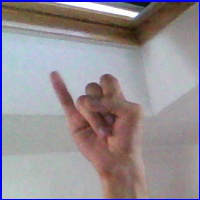

In [30]:
import PIL
img = PIL.Image.open(files[0])
print(f"Image Dims: {img.shape}")
img

**Define target input dimensions**

In [31]:
# size_1_1 = (224, 224)
# size_3_2 = (224, 336)
# size_4_3 = (216, 288)
size_16_9 = (216, 384)
# size_16_9_l = (288, 512)

In [32]:
input_dims = size_16_9

**Define Transforms**

In [33]:
inspect_default_args(aug_transforms)

,Default Value
mult,1.0
do_flip,True
flip_vert,False
max_rotate,10.0
min_zoom,1.0
max_zoom,1.1
max_lighting,0.2
max_warp,0.2
p_affine,0.75
p_lighting,0.75


In [34]:
item_tfms = [FlipItem(p=1.0), Resize(input_dims, method=ResizeMethod.Pad, pad_mode=PadMode.Border)]

batch_tfms = [
    Contrast(max_lighting=0.25),
    Saturation(max_lighting=0.25),
    Hue(max_hue=0.05),
    *aug_transforms(
        size=input_dims, 
        mult=1.0,
        do_flip=False,
        flip_vert=False,
        max_rotate=0.0,
        min_zoom=0.5,
        max_zoom=1.5,
        max_lighting=0.5,
        max_warp=0.2, 
        p_affine=0.0,
        pad_mode=PadMode.Border),
    Normalize.from_stats(mean=mean, std=std)
]

**Define batch size**
* Adjust based on available GPU memory.

In [35]:
bs = 128

**Define DataLoaders object**

In [36]:
inspect_default_args(ImageDataLoaders.from_folder)

,Default Value
cls,None
path,None
train,train
valid,valid
valid_pct,None
seed,None
vocab,None
item_tfms,None
batch_tfms,None
bs,64


In [37]:
dls = ImageDataLoaders.from_folder(
    path=dataset_path/'ASL', 
    valid_pct=0.2, 
    bs=bs, 
    item_tfms=item_tfms, 
    batch_tfms=batch_tfms
)

**Verify DataLoaders object**

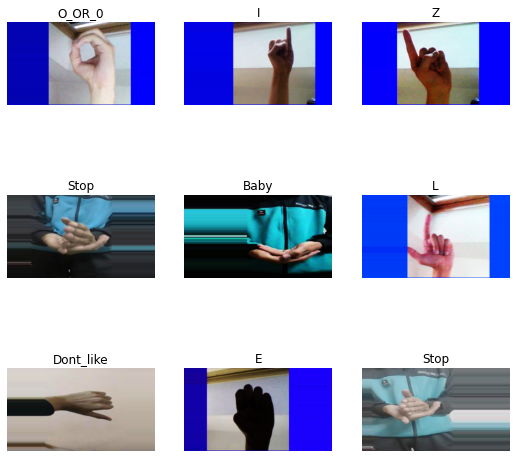

In [38]:
dls.train.show_batch()

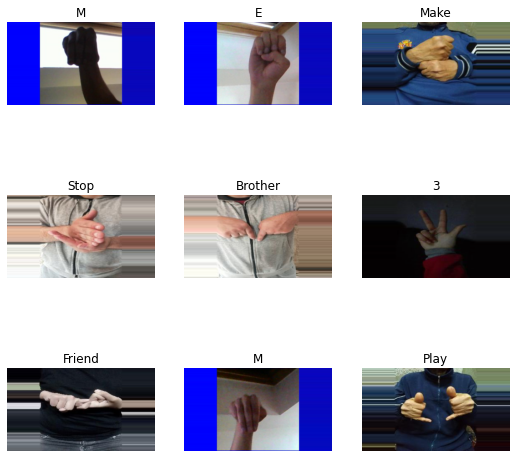

In [39]:
dls.valid.show_batch()

**Apply training split transforms to validation split**

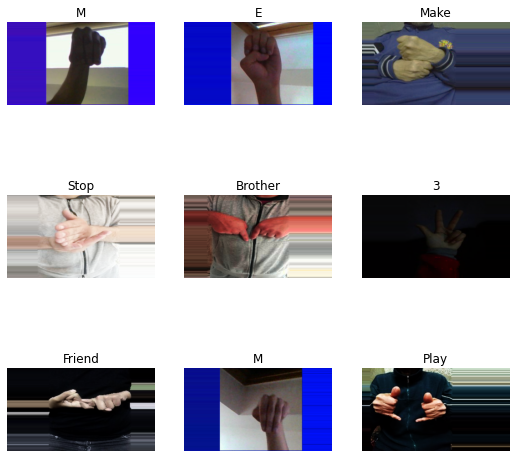

In [40]:
with dls.valid.dataset.set_split_idx(0): dls[1].show_batch()

**Inspect Learner parameters**

In [41]:
inspect_default_args(vision_learner)

,Default Value
dls,None
arch,None
normalize,True
n_out,None
pretrained,True
loss_func,None
opt_func,<function Adam at 0x7f7e9bf67f40>
lr,0.001
splitter,None
cbs,None


**Define [metrics](https://docs.fast.ai/metrics.html)**

In [42]:
metrics = [error_rate, accuracy]

**Define Learner object**

In [43]:
learn = vision_learner(dls, model_name, metrics=metrics).to_fp16()

**Find learning rate**

In [44]:
inspect_default_args(learn.lr_find)

,Default Value
self,None
start_lr,0.0
end_lr,10
num_it,100
stop_div,True
show_plot,True
suggest_funcs,<function valley at 0x7f7e9bcdc790>


**Define [suggestion methods](https://docs.fast.ai/callback.schedule.html#Suggestion-Methods)**

In [45]:
suggest_funcs = [valley, minimum, steep]

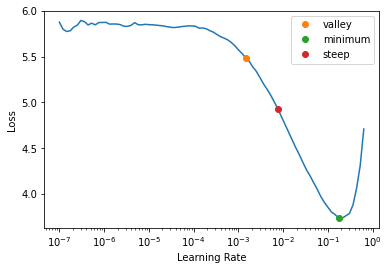

In [46]:
with dls.valid.dataset.set_split_idx(0): learn.lr_find(suggest_funcs=suggest_funcs)

**Define learning rate**

In [47]:
lr = 3e-3
lr

0.003

**Define number of epochs**

In [48]:
epochs = 3

**Fine tune model**

In [49]:
inspect_default_args(learn.fine_tune)

,Default Value
self,None
epochs,None
base_lr,0.002
freeze_epochs,1
lr_mult,100
pct_start,0.3
div,5.0
lr_max,None
div_final,100000.0
wd,None


In [50]:
with dls.valid.dataset.set_split_idx(0): learn.fine_tune(epochs, base_lr=lr)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.143378,0.063845,0.022512,0.977488,09:24


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.036883,0.014203,0.005123,0.994877,13:48
1,0.017915,0.007847,0.003596,0.996404,13:43
2,0.009706,0.006360,0.003325,0.996675,14:28


**Select a test image**

In [51]:
import PIL

In [52]:
test_file = files[0]
test_file.name

'J1491.jpg'

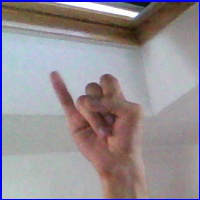

In [53]:
test_img = PIL.Image.open(test_file)
test_img

**Make a prediction on a single image using a [fastai.vision.core.PILImage](https://docs.fast.ai/vision.core.html#PILImage)**

In [54]:
learn.predict(PILImage(test_img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)))

('J',
 TensorBase(22),
 TensorBase([9.9655e-11, 8.7721e-15, 2.7388e-15, 2.2086e-17, 1.9550e-10, 1.0362e-10,
         5.8977e-12, 6.0181e-14, 9.7478e-15, 2.5907e-12, 2.9498e-15, 2.9560e-14,
         8.3893e-13, 3.8242e-16, 6.5890e-12, 1.2617e-13, 3.0315e-12, 4.6032e-12,
         1.3408e-11, 6.0938e-12, 1.4924e-13, 1.0953e-05, 9.9999e-01, 1.1653e-09,
         3.5801e-13, 6.7117e-16, 3.4138e-12, 6.5838e-14, 1.2468e-14, 2.4359e-15,
         9.5543e-12, 2.8452e-12, 7.6374e-14, 4.2585e-15, 6.6136e-10, 1.8283e-14,
         3.0842e-12, 2.8797e-12, 5.4304e-09, 1.5803e-09, 7.0000e-09, 1.3149e-11,
         8.5310e-12, 1.3200e-11, 1.2714e-14, 1.9150e-11, 1.5516e-14, 3.4851e-10,
         1.9926e-13, 3.9337e-10, 1.0749e-13]))

**Make predictions for a group of images**

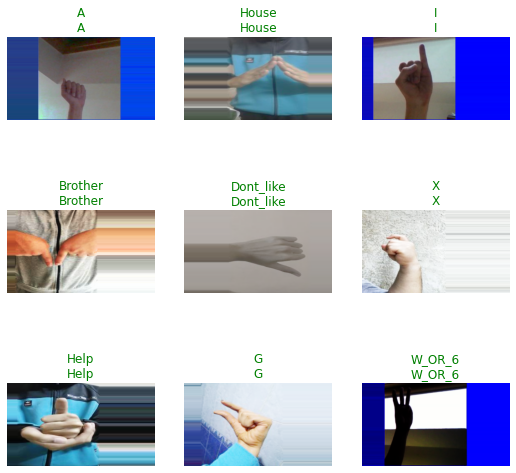

In [55]:
with dls.valid.dataset.set_split_idx(0): learn.show_results()

**Define an Interpretation object**

In [56]:
with dls.valid.dataset.set_split_idx(0): interp = Interpretation.from_learner(learn)

**Plot top losses**

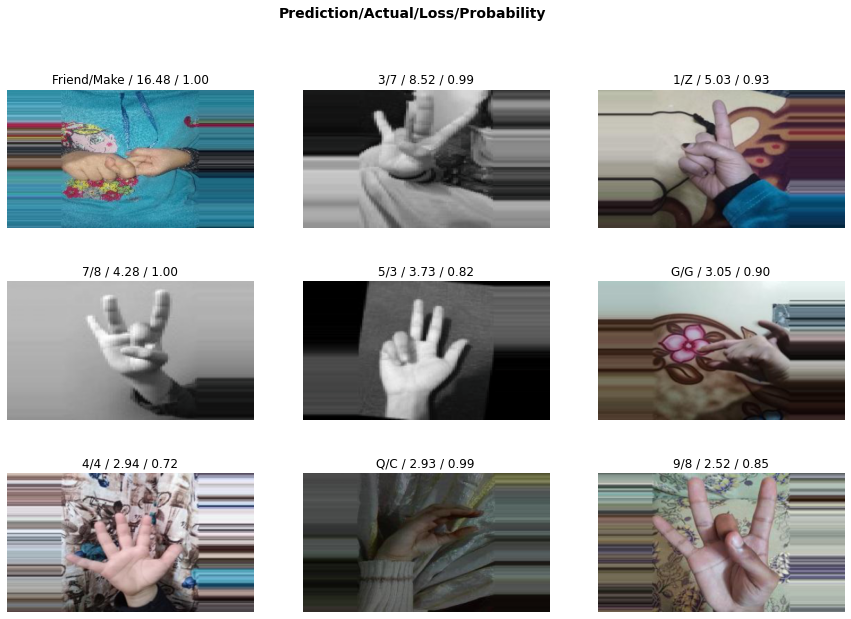

In [57]:
with dls.valid.dataset.set_split_idx(0): interp.plot_top_losses(k=9, figsize=(15,10))

**Inspect the `after_item` pipeline**

In [58]:
learn.dls.after_item

Pipeline: FlipItem -- {'p': 1.0} -> Resize -- {'size': (384, 216), 'method': 'pad', 'pad_mode': 'border', 'resamples': (<Resampling.BILINEAR: 2>, <Resampling.NEAREST: 0>), 'p': 1.0} -> ToTensor

**Inspect the `after_batch` pipeline**

In [59]:
learn.dls.after_batch

Pipeline: IntToFloatTensor -- {'div': 255.0, 'div_mask': 1} -> Warp -- {'magnitude': 0.2, 'p': 1.0, 'draw_x': None, 'draw_y': None, 'size': (216, 384), 'mode': 'bilinear', 'pad_mode': 'border', 'batch': False, 'align_corners': True, 'mode_mask': 'nearest'} -> Contrast -- {'max_lighting': 0.25, 'p': 1.0, 'draw': None, 'batch': False} -> Saturation -- {'max_lighting': 0.25, 'p': 1.0, 'draw': None, 'batch': False} -> Hue -- {'p': 1.0} -> Brightness -- {'max_lighting': 0.5, 'p': 1.0, 'draw': None, 'batch': False} -> Normalize -- {'mean': tensor([[[[0.4850]],

         [[0.4560]],

         [[0.4060]]]], device='cuda:0'), 'std': tensor([[[[0.2290]],

         [[0.2240]],

         [[0.2250]]]], device='cuda:0'), 'axes': (0, 2, 3)}

**Reset test image**

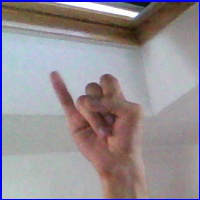

In [60]:
test_img = PIL.Image.open(test_file)
test_img

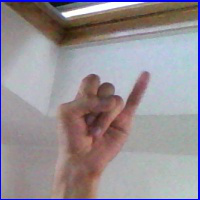

In [61]:
test_img = test_img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
test_img

In [62]:
test_img.size

(200, 200)

In [63]:
min(test_img.size)

200

In [64]:
min_dim = test_img.size.index(min(test_img.size))
max_dim = 1 - min_dim

In [65]:
target_dim = 224

**Set input dims**

In [66]:
inp_dims = [0,0]
inp_dims[min_dim] = target_dim
inp_dims[max_dim] = int(test_img.size[max_dim] / (test_img.size[min_dim]/target_dim))
inp_dims

[224, 224]

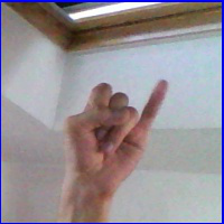

In [67]:
resized_img = test_img.resize(inp_dims)
resized_img

**Convert image to tensor**

In [68]:
img_tensor = tensor(resized_img).permute(2, 0, 1)
img_tensor.shape, img_tensor

(torch.Size([3, 224, 224]),
 tensor([[[  0,   0,   0,  ...,   1,   0,   0],
          [  0,   4,   2,  ...,   9,   2,   0],
          [  5,  82,  99,  ...,  74,   8,   0],
          ...,
          [  3, 127, 154,  ..., 141,   0,   3],
          [  3, 102, 125,  ..., 120,   0,   0],
          [  0,   0,   4,  ...,   0,   1,   0]],
 
         [[  4,   1,   2,  ...,   0,   2,   5],
          [  2,   1,   0,  ...,   0,   0,   5],
          [  0,  75,  91,  ...,  63,   1,   1],
          ...,
          [  3, 126, 150,  ..., 151,   0,   0],
          [  7, 105, 122,  ..., 127,   1,   0],
          [  8,   5,   3,  ...,   4,   6,   2]],
 
         [[253, 254, 255,  ..., 253, 255, 254],
          [244, 220, 199,  ..., 209, 237, 255],
          [212, 222, 180,  ..., 188, 211, 251],
          ...,
          [196, 225, 171,  ..., 238, 204, 255],
          [207, 247, 222,  ..., 242, 218, 255],
          [223, 203, 193,  ..., 219, 247, 254]]], dtype=torch.uint8))

**Scale tensor values**

In [69]:
scaled_tensor = img_tensor.float().div_(255)

**Prepare mean values**

In [70]:
mean_tensor = tensor(mean).view(1,1,-1).permute(2, 0, 1)
mean_tensor.shape, mean_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.4850]],
 
         [[0.4560]],
 
         [[0.4060]]]))

**Prepare std values**

In [71]:
std_tensor = tensor(std).view(1,1,-1).permute(2, 0, 1)
std_tensor.shape, std_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.2290]],
 
         [[0.2240]],
 
         [[0.2250]]]))

**Normalize and batch image tensor**

In [72]:
normalized_tensor = (scaled_tensor - mean_tensor) / std_tensor
batched_tensor = normalized_tensor.unsqueeze(dim=0)
batched_tensor.shape, batched_tensor

(torch.Size([1, 3, 224, 224]),
 tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1008, -2.1179, -2.1179],
           [-2.1179, -2.0494, -2.0837,  ..., -1.9638, -2.0837, -2.1179],
           [-2.0323, -0.7137, -0.4226,  ..., -0.8507, -1.9809, -2.1179],
           ...,
           [-2.0665,  0.0569,  0.5193,  ...,  0.2967, -2.1179, -2.0665],
           [-2.0665, -0.3712,  0.0227,  ..., -0.0629, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.0494,  ..., -2.1179, -2.1008, -2.1179]],
 
          [[-1.9657, -2.0182, -2.0007,  ..., -2.0357, -2.0007, -1.9482],
           [-2.0007, -2.0182, -2.0357,  ..., -2.0357, -2.0357, -1.9482],
           [-2.0357, -0.7227, -0.4426,  ..., -0.9328, -2.0182, -2.0182],
           ...,
           [-1.9832,  0.1702,  0.5903,  ...,  0.6078, -2.0357, -2.0357],
           [-1.9132, -0.1975,  0.1001,  ...,  0.1877, -2.0182, -2.0357],
           [-1.8957, -1.9482, -1.9832,  ..., -1.9657, -1.9307, -2.0007]],
 
          [[ 2.6051,  2.6226,  2.6400,  ...,  2.6051,  

**Pass tensor to model**

In [73]:
with torch.no_grad():
    preds = learn.model.cuda()(batched_tensor.cuda())
preds

TensorBase([[  1.5531,  -8.0990,  -8.6721, -14.9587,   7.9085,   4.9332,   1.1211,
          -5.0751,  -6.2369,  -2.5851,  -7.0747,  -6.0743,  -2.2732, -10.5184,
           1.4623,  -2.2958,  -1.4619,  -2.1956,  -1.3258,  -3.0084,  -4.0722,
          15.7325,  32.5119,   6.3926,  -6.7963, -11.1853,  -2.0640,  -7.5754,
          -7.4062,  -7.4315,  -2.9132,  -2.2959,  -4.9033,  -7.7000,   2.9854,
          -6.3091,  -0.4858,  -2.2739,   7.9426,   3.4297,   7.9970,  -0.3321,
           0.1243,   1.2176,  -9.5849,   2.8612,  -8.3178,   2.9500,  -4.2803,
           3.0594,  -2.3413]], device='cuda:0')

**Process model output**

In [74]:
torch.nn.functional.softmax(preds, dim=1)

TensorBase([[3.5872e-14, 2.3062e-18, 1.3002e-18, 2.4198e-21, 2.0648e-11, 1.0537e-12,
         2.3290e-14, 4.7442e-17, 1.4847e-17, 5.7221e-16, 6.4230e-18, 1.7468e-17,
         7.8167e-16, 2.0521e-19, 3.2759e-14, 7.6423e-16, 1.7594e-15, 8.4476e-16,
         2.0160e-15, 3.7472e-16, 1.2934e-16, 5.1616e-08, 1.0000e+00, 4.5347e-12,
         8.4851e-18, 1.0533e-19, 9.6359e-16, 3.8931e-18, 4.6107e-18, 4.4958e-18,
         4.1217e-16, 7.6414e-16, 5.6335e-17, 3.4369e-18, 1.5025e-13, 1.3812e-17,
         4.6695e-15, 7.8113e-16, 2.1363e-11, 2.3430e-13, 2.2559e-11, 5.4455e-15,
         8.5952e-15, 2.5649e-14, 5.2192e-19, 1.3269e-13, 1.8531e-18, 1.4502e-13,
         1.0504e-16, 1.6179e-13, 7.3018e-16]], device='cuda:0')

In [75]:
preds.argmax()

TensorBase(22, device='cuda:0')

In [76]:
torch.nn.functional.softmax(preds, dim=1)[0][preds.argmax()]

TensorBase(1., device='cuda:0')

**Get the class labels**

In [77]:
learn.dls.vocab

['1', '3', '4', '5', '7', '8', '9', 'A', 'B', 'Baby', 'Brother', 'C', 'D', 'Dont_like', 'E', 'F', 'Friend', 'G', 'H', 'Help', 'House', 'I', 'J', 'K', 'L', 'Like', 'Love', 'M', 'Make', 'More', 'N', 'Name', 'No', 'O_OR_0', 'P', 'Pay', 'Play', 'Q', 'R', 'S', 'Stop', 'T', 'U', 'V_OR_2', 'W_OR_6', 'With', 'X', 'Y', 'Yes', 'Z', 'nothing']

**Get the predicted class label**

In [78]:
learn.dls.vocab[torch.nn.functional.softmax(preds, dim=1).argmax()]

'J'

**Define ONNX file name**

In [79]:
learn.arch

'convnext_tiny'

In [80]:
onnx_file_name = f"{dataset_path.name}-{learn.arch}.onnx"
onnx_file_name

'asl-and-some-words-convnext_tiny.onnx'

**Export trained model to ONNX**

In [81]:
torch.onnx.export(learn.model.cpu(),
                  batched_tensor,
                  onnx_file_name,
                  export_params=True,
                  opset_version=11,
                  do_constant_folding=True,
                  input_names = ['input'],
                  output_names = ['output'],
                  dynamic_axes={'input': {2 : 'height', 3 : 'width'}}
                 )

**Generate a torchscript module using the test image** 

In [82]:
traced_script_module = torch.jit.trace(learn.model.cpu(), batched_tensor)

**Verify the torchscript module's accuracy**

In [83]:
with torch.no_grad():
    torchscript_preds = traced_script_module(batched_tensor)
learn.dls.vocab[torch.nn.functional.softmax(torchscript_preds, dim=1).argmax()]

'J'

**Define Torchscript file name**

In [84]:
module_file_name = f"{dataset_path.name}-{learn.arch}.pt"
module_file_name

'asl-and-some-words-convnext_tiny.pt'

**Generate a torchscript module using the target input dimensions and save it to a file** 

In [85]:
torch.randn(1, 3, *input_dims).shape

torch.Size([1, 3, 216, 384])

In [86]:
traced_script_module = torch.jit.trace(learn.model.cpu(), torch.randn(1, 3, *input_dims))
traced_script_module.save(module_file_name)

**Export class labels**

In [87]:
import json

class_labels = {"classes": list(learn.dls.vocab)}
class_labels_file_name = f"{dataset_path.name}-classes.json"

with open(class_labels_file_name, "w") as write_file:
    json.dump(class_labels, write_file)

**Export model normalization stats**

In [88]:
normalization_stats = {"mean": list(mean), "std": list(std)}
normalization_stats_file_name = f"{learn.arch}-normalization_stats.json"

with open(normalization_stats_file_name, "w") as write_file:
    json.dump(normalization_stats, write_file)